Top Frequently Bought Together Products

                                           Product Pair  Frequency
1993                (Hon Olson Stacker Chairs, Staples)          3
567         (Satellite Sectional Post Binders, Staples)          3
1276  (#10 White Business Envelopes,4 1/8 x 9 1/2, S...          3
2064  (Hoover Shoulder Vac Commercial Portable Vacuu...          3
1280                               (Newell 34, Staples)          3
1429              (KI Adjustable-Height Table, Staples)          3
5010                              (Staples, Xerox 1916)          3
7265      (Adjustable Depth Letter/Legal Cart, Staples)          3
3790                 (Avery Non-Stick Binders, Staples)          2
1495  (Cisco SPA508G, Global Commerce Series High-Ba...          2


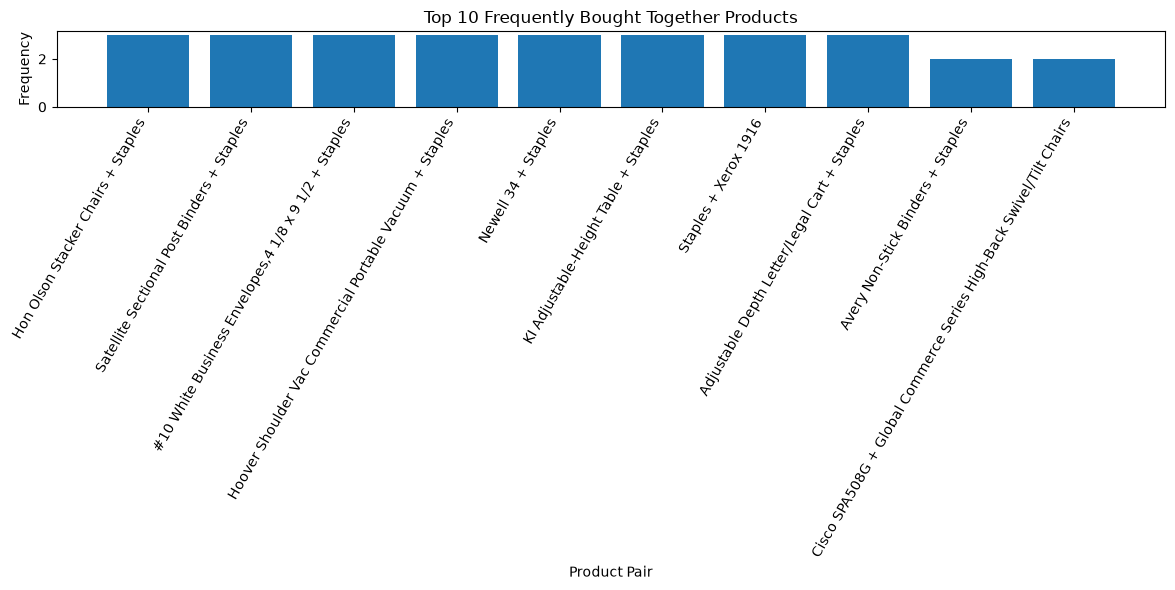

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv("cleaned_dataset.csv")

# ------------------------------------------
# Check Required Columns
# ------------------------------------------

required_columns = ["Order ID", "Product Name"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"{col} column not found in dataset.")

# ------------------------------------------
# Group Products by Order
# ------------------------------------------

orders = (
    df.groupby("Order ID")["Product Name"]
    .apply(list)
)

# ------------------------------------------
# Generate Product Pairs
# ------------------------------------------

product_pairs = []

for products in orders:

    unique_products = list(set(products))

    if len(unique_products) > 1:
        product_pairs.extend(
            combinations(sorted(unique_products), 2)
        )

# ------------------------------------------
# Count Product Pair Frequency
# ------------------------------------------

pair_counts = Counter(product_pairs)

recommendation_df = pd.DataFrame(
    pair_counts.items(),
    columns=["Product Pair", "Frequency"]
)

recommendation_df = recommendation_df.sort_values(
    by="Frequency",
    ascending=False
)

# ------------------------------------------
# Display Top Recommendations
# ------------------------------------------

print("Top Frequently Bought Together Products\n")

print(recommendation_df.head(10))

# ------------------------------------------
# Visualization
# ------------------------------------------

top10 = recommendation_df.head(10)

labels = [
    f"{pair[0]} + {pair[1]}"
    for pair in top10["Product Pair"]
]

plt.figure(figsize=(12,6))

plt.bar(labels, top10["Frequency"])

plt.title("Top 10 Frequently Bought Together Products")
plt.xlabel("Product Pair")
plt.ylabel("Frequency")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.show()

# ------------------------------------------
# Save Recommendations
# ------------------------------------------

recommendation_df.to_csv(
    "product_recommendations.csv",
    index=False
)

